# IEE 575 — Warm-Up Checkpoint & Bridge to Gaussian Processes

**Before you start:**
- Make a copy of this notebook (`File → Save a copy in Drive`)
- Work through each exercise **in order**
- Every exercise follows the same pattern:
  1. **Read** the setup and the question
  2. **Predict** what you think will happen (write it down!)
  3. **Write / Fix** the code
  4. **Run** it
  5. **Explain** — if your prediction was wrong, figure out *why*

> ⚠️ **Rule:** Do not skip the "Predict" step. Getting it wrong is the point — that's where learning happens.

---

# Python Warmup

## Part 1 — Quick-Fire Warm-Up 🔥

These exercises cover the building blocks we need solid before going deeper into Gaussian Processes. If any of these feel shaky, that's exactly why we're doing them.

### Exercise 1 — Functions and `np.linspace`

**Context:** We need to evaluate mathematical functions on a grid of points constantly in this course. `np.linspace` creates that grid; a Python function wraps the math.

**Your task:** Complete the function below so it returns $f(x) = x \sin(x)$, then plot it on 200 points between $-3\pi$ and $3\pi$.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def f(x):
    # TODO: return f(x) = x sin(x)
    return  ...

# TODO: Create 200 evenly spaced points from -3π to 3π
x = ...

# Plot
plt.figure(figsize=(8, 3))
plt.plot(x, f(x))

plt.xlabel('x')
plt.ylabel('f(x)')
plt.title(r'$f(x) = x \sin(x)$')

plt.axhline(0, color='gray', linewidth=0.5)
plt.grid(True, alpha=0.3)

plt.show()

**Predict before running:** What will the curve look like? Will the peaks get bigger or stay the same as $|x|$ increases? Why?

**Your prediction:** *(write here)*

---

### Exercise 2 — Functions, Sampling, and Overlaying Curves

**Context:** In many problems, we define functions, evaluate them on a grid of points, and visualize the results. This exercise brings those steps together.

---

### Your task:

1. Define three functions:
   - $ f_1(x) = \sin(x) $
   - $ f_2(x) = \cos(x) $
   - $ f_3(x) = \sin(x) + \cos(x) $

2. Create **300 evenly spaced points** between $0$ and $2\pi$

3. Evaluate all three functions on those points

4. Plot all three curves on the **same axes**

5. Add a legend so each curve is clearly labeled

---

### Predict (before writing any code):

Will $ \sin(x) + \cos(x) $ ever be larger than $\sqrt 2$?

Think carefully — don’t just guess. You should be able to justify your answer after plotting.

---

### Goal:

By the end of this exercise, you should be comfortable with:
- defining functions
- generating input values using `np.linspace`
- evaluating functions on arrays
- plotting multiple curves on the same axes

In [ ]:
# Exercise 2 — Functions, Sampling, and Overlaying Curves

import numpy as np
import matplotlib.pyplot as plt

# TODO: define the three functions
def f1(x):
    return None

def f2(x):
    return None

def f3(x):
    return None


# TODO: create 300 evenly spaced points from 0 to 2π
x = None


# TODO: evaluate the functions
y1 = None
y2 = None
y3 = None


# Plot
plt.figure(figsize=(8, 3))

plt.plot(x, y1, label='sin(x)')

# =====================================================
# TODO:
# Plot y2 and y3 with appropriate labels
# =====================================================

# plt.plot(...)

# =====================================================

plt.legend()
plt.grid(True, alpha=0.3)
plt.title('Three curves, one plot')

plt.show()


# Predict before running:
# Will sin(x) + cos(x) ever be larger than 1.5?

### Exercise 3 — Adding Noise (The Noisy Sensor Revisited)

**Context:** Real sensors don't give perfect readings. We model this by adding Gaussian noise: $y_{\text{observed}} = f(x) + \epsilon$, where $\epsilon \sim \mathcal{N}(0, \sigma^2)$.

**Your task:** The code below is supposed to generate 15 noisy observations of $f(x) = \sin(x)$ and plot them on top of the true curve. **There are 2 bugs.** Find and fix them.

In [ ]:
np.random.seed(42)

# True function on a fine grid
x_fine = np.linspace(0, 2 * np.pi, 200)
y_true = np.sin(x_fine)

# 15 random sensor locations
x_sensors = np.random.uniform(0, 2 * np.pi, size=15)
y_sensors = np.sin(x_sensors) + np.random.normal(0, 0.2, size=1)  # BUG 1

plt.figure(figsize=(8, 3))
plt.plot(x_fine, y_true, 'k-', linewidth=1.5, label='True signal')
plt.plot(x_sensors, y_sensors, 'r-', markersize=8, label='Noisy obs')  # BUG 2
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.title('Noisy sensor observations')
plt.show()

**Bugs to find:**
1. The noise array has the wrong number of elements. How should it match?
2. `plt.plot` connects points with lines by default. For scattered observations, what's the better function? (Hint: or is the current code already fine given the format string?)

**Your fixes & explanation:** *(write here)*

---

### Exercise 4 — Uncertainty Bands with `fill_between`

**Context:** When we don't trust our measurements perfectly, we want to show a **band** of plausible values — not just a line. This is the visual foundation for everything GP-related.

**Your task:** Complete the code to shade a ±0.3 uncertainty band around $\sin(x)$.

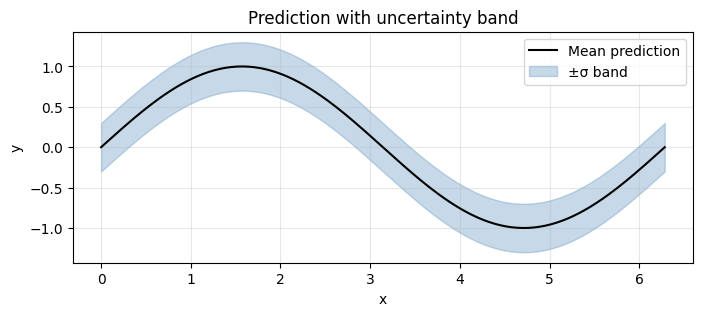

In [6]:
x = np.linspace(0, 2 * np.pi, 200)
y = np.sin(x)

sigma = 0.3  # uncertainty width

plt.figure(figsize=(8, 3))
plt.plot(x, y, 'k-', linewidth=1.5, label='Mean prediction')

# Shade the region between (y - sigma) and (y + sigma)
plt.fill_between(..., ..., ..., alpha=0.3, color='steelblue', label='±σ band')

plt.legend()
plt.xlabel('x')
plt.ylabel('y')
plt.title('Prediction with uncertainty band')
plt.grid(True, alpha=0.3)
plt.show()

**Think about it:** This band has **constant width** everywhere. Is that realistic for a sensor? Would you expect the same uncertainty in a region with lots of measurements vs. a region with none?

**Your answer:** *(write here)*

> 💡 This is exactly the limitation we'll fix with Gaussian Processes — they give **wider bands where data is sparse** and **narrower bands near observations**.

---

## Part 2 — Thinking in 2D: `meshgrid`, Contour Plots, and 3D Surfaces

So far, everything has been 1D: one input \(x\), one output \(y\). But soon we need to:
- **Visualize covariance matrices** — which are 2D grids of numbers
- **Plot multivariate Gaussians** — which are surfaces over 2D input spaces

This section gives you the plotting tools for that. The math comes later — right now we're just building visual fluency.

---


### Exercise 5 — What Does `np.meshgrid` Actually Do?

**Context:** To evaluate a 2D function $f(x_1, x_2)$, we need every combination of $x_1$ and $x_2$. That's exactly what `np.meshgrid` creates.

---

In [ ]:

### Starter code:

x1 = np.array([1, 2, 3])       # values along x1-axis
x2 = np.array([10, 20])        # values along x2-axis

X1, X2 = np.meshgrid(x1, x2)

print("x1 (original):", x1)
print("x2 (original):", x2)
print()

print("X1 (meshgrid):")
print(X1)
print("Shape:", X1.shape)
print()

print("X2 (meshgrid):")
print(X2)
print("Shape:", X2.shape)


**After running:** Fill in this mental model:

- `X1` takes the `x1` values and __________ them across rows (one row per `x2` value)
- `X2` takes the `x2` values and __________ them across columns (one column per `x1` value)
- Together, `(X1[i,j], X2[i,j])` gives the __________ at grid position `(i, j)`

**Your answers:** *(fill in the blanks)*

---

### Exercise 6 — Your First 2D Function on a Grid

**Context:** We now move from 1D to 2D. Instead of evaluating a function at points along a line, we evaluate it over a grid of \((x_1, x_2)\) values.

---

### Your task:

1. Create a grid of values using `np.linspace` and `np.meshgrid`
2. Evaluate the function  
   $f(x_1, x_2) = x_1^2 + x_2^2$
   on that grid
3. Visualize the result using a **filled contour plot**

---

In [ ]:
### Starter code:

# Step 1: Create a grid
x1 = np.linspace(-3, 3, 100)
x2 = np.linspace(-3, 3, 100)
X1, X2 = np.meshgrid(x1, x2)

# =====================================================
# TODO:
# Compute Z = x1^2 + x2^2 using the meshgrid arrays
# =====================================================

Z = None

# =====================================================

# Step 3: Contour plot
plt.figure(figsize=(6, 5))

# =====================================================
# TODO:
# Use plt.contourf to visualize Z
# Add a colorbar
# Optionally overlay contour lines
# =====================================================

# cp = plt.contourf(...)
# plt.colorbar(...)

# =====================================================

plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.title('Contour plot of $f(x_1, x_2)$')
plt.axis('equal')

plt.show()

**Predict before running:** What shape will the contours be? (Circles? Ellipses? Squares?) Why?

**Your prediction:** *(write here)*

**After running:** The center of the "bowl" is at $(0, 0)$ where $f = 0$. Notice how the contour lines are **level sets** — every point on the same contour has the same function value. You'll see this exact pattern when we plot Gaussian distributions.

---

### Exercise 7 — Elliptical Contours (Sneak Preview of Covariance)

**Context:** In 2D, the *shape* of contours tells you about relationships between variables.

- Circular contours → variables are independent
- Elliptical contours → variables are correlated

This is exactly what covariance will control later.

---

### Your task:

1. Modify the function to:
   $f(x_1, x_2) = x_1^2 + x_2^2 + x_1 x_2$

2. Compute this function on the grid

3. Compare the contour plot to the original "bowl"

---

In [ ]:

### Starter code:

x1 = np.linspace(-3, 3, 100)
x2 = np.linspace(-3, 3, 100)
X1, X2 = np.meshgrid(x1, x2)

# =====================================================
# TODO:
# Compute Z = x1^2 + x2^2 + x1 * x2 using X1 and X2
# =====================================================

Z = ...

# =====================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: original bowl
Z_bowl = X1**2 + X2**2
axes[0].contourf(X1, X2, Z_bowl, levels=20, cmap='viridis')
axes[0].contour(X1, X2, Z_bowl, levels=20, colors='white', linewidths=0.3, alpha=0.5)
axes[0].set_title('$x_1^2 + x_2^2$ (no cross-term)')
axes[0].set_xlabel('$x_1$')
axes[0].set_ylabel('$x_2$')
axes[0].set_aspect('equal')

# Right: new function
axes[1].contourf(X1, X2, Z, levels=20, cmap='viridis')
axes[1].contour(X1, X2, Z, levels=20, colors='white', linewidths=0.3, alpha=0.5)
axes[1].set_title('$x_1^2 + x_2^2 + x_1 x_2$')
axes[1].set_xlabel('$x_1$')
axes[1].set_ylabel('$x_2$')
axes[1].set_aspect('equal')

plt.tight_layout()
plt.show()


**After running:** The cross-term $x_1 x_2$ tilted the contours into ellipses. This is exactly what happens when two variables are **correlated**.

> 💡 **Coming soon:** When we define a GP kernel $k(x, x')$, the entries of the covariance matrix control these shapes. A kernel that says "nearby points are correlated" produces tilted, structured covariance — not boring circles.

---

### Exercise 8 — 3D Surface Plots

**Context:** We'll use 3D surfaces to visualize the multivariate Gaussian density — the classic "bell" in 2D. Let's build the plotting skill first with a simple function.

**Your task:** Plot the "bowl" $f(x_1, x_2) = x_1^2 + x_2^2$ as a 3D surface, then modify it to plot an **inverted Gaussian bump**: $f(x_1, x_2) = \exp\!\left(-\frac{x_1^2 + x_2^2}{2}\right)$

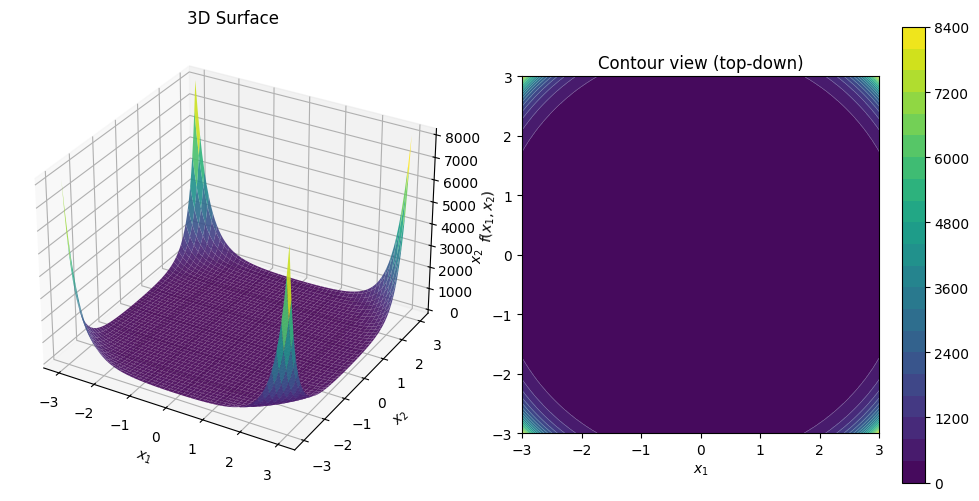

In [11]:
from mpl_toolkits.mplot3d import Axes3D

x1 = np.linspace(-3, 3, 100)
x2 = np.linspace(-3, 3, 100)
X1, X2 = np.meshgrid(x1, x2)

# ============ YOUR CODE: compute Z for the Gaussian bump ============
Z = np.exp((X1**2 + X2**2)/2.)  # exp(-(x1^2 + x2^2) / 2)
# =====================================================================

fig = plt.figure(figsize=(10, 5))

# Left: 3D surface
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot_surface(X1, X2, Z, cmap='viridis', alpha=0.9, edgecolor='none')
ax1.set_xlabel('$x_1$')
ax1.set_ylabel('$x_2$')
ax1.set_zlabel('$f(x_1, x_2)$')
ax1.set_title('3D Surface')

# Right: top-down contour view of the same thing
ax2 = fig.add_subplot(122)
cp = ax2.contourf(X1, X2, Z, levels=20, cmap='viridis')
plt.colorbar(cp, ax=ax2)
ax2.contour(X1, X2, Z, levels=20, colors='white', linewidths=0.3, alpha=0.5)
ax2.set_xlabel('$x_1$')
ax2.set_ylabel('$x_2$')
ax2.set_title('Contour view (top-down)')
ax2.set_aspect('equal')

plt.tight_layout()
plt.show()

**Observe:** The 3D surface and the contour plot show the **same** information from different viewpoints. The contour plot is a "top-down photograph" of the surface. In this course, we'll often prefer contour plots because they're easier to read — but it helps to know the 3D shape they came from.

> 💡 **What you just plotted is an unnormalized 2D Gaussian density** with mean $(0,0)$ and identity covariance. When we do multivariate Gaussians next week, you'll recognize this shape immediately.

---

# Gaussian Process Fundamentals

## 1. Univariate Normal Distribution

*   A random variable X is normally distributed with mean $\mu$ and variance $\sigma^2$ if it has the probability density function of X as:
$$ f(x) = \frac{1}{\sqrt{2 \pi} \sigma} exp{\left(-\frac{{\left(x - \mu \right)}^{2}}{2 \sigma^{2}}\right)}$$

*   In this expression, you see the squared difference between the variable $x$ and its mean, $\mu$.
*   This value will be minimized when $x$ is equal to $\mu$.
*   The quantity $-\frac{{x-\mu}^2}{\sigma^2}$ will take its largest value when $x$ is equal to $\mu$ or likewise since the exponential function is a monotone function, the normal density takes a maximum value when $x$ is equal to $\mu$.
*   The variance $\sigma^2$ defines the spread of the distribution about that maximum. If it is large, then the spread is going to be large, otherwise, if the value is small, then the spread will be small.




If $X$ is random variable that follows a normal distribution with mean $\mu$ and variance $\sigma^2$, then we will denote it as $X \sim \mathcal{N}(\mu, \sigma^2)$.    

    
If you are not familiar, play around with this link: https://demonstrations.wolfram.com/TheNormalDistribution/


---

**Functions needed from NumPy**

For the PDF implementation:

* `np.sqrt()` → normalization constant
* `np.pi` → π
* `np.exp()` → exponential


For data generation:

* `np.linspace(start, stop, num)` → create x-axis values
* `np.random.normal(mu, sigma, size)` → generate samples

---

**Functions needed from Matplotlib**

For plotting the PDF:

* `plt.plot(x, y)`



For histogram:

* `plt.hist(samples, bins=..., density=True)`
   `density=True` is required



In [18]:
import numpy as np
import matplotlib.pyplot as plt

def univariate_density(x, mu, sigma):
    # TODO: implement the normal PDF
    pass

x_vals = np.linspace(-6, 6, 1000)

mu, sigma = 0, 1

# TODO: compute y values using your function

# TODO: plot the PDF

# TODO: generate 1000 samples from N(mu, sigma)

# TODO: plot histogram of samples (normalized)

plt.show()

What happens on changing the mean and the variance?

In [ ]:
params = [(0,1), (0,5), (1,0.5)]

for mu, sigma in params:
    # TODO:
    # 1. compute PDF
    # 2. plot it
    # 3. generate samples
    # 4. plot histogram
    pass

In [ ]:
# You can also use norm.pdf(). Can someone tell me the parameters?

## 2. The Multivariate Case


The multivariate normal distribution of a k-dimensional random vector  $\mathbf{X} = (X_1, X_2, ..., X_k)^{T}$ is written as $\mathbf{X} \sim \mathcal{N}(\mathbf{\mu}, \Sigma)$.
The probability density function is given as follows:
  $$f(\mathbf{x}) = \frac{1}{{(2\pi)^{k/2}|\Sigma|^{1/2}}}\exp\left(-\frac{1}{2}(\mathbf{x}-\mathbf{\mu})^{T}\Sigma^{-1}(\mathbf{x}-\mathbf{\mu})\right)$$
  
where, $\mathbf{\mu} = E[\mathbf{X}] = (E[X_1], E[X_2], ..., E[X_k])^{T}$ and $\Sigma_{i,j} = E[(X_i-\mu_i)(X_j-\mu_j)] = Cov[X_i, X_j]$
    

  
*Fun fact: correctly constructed covariance matrices are always symmetric and positive semi-definite. And thus invertible.*

Let us look at the covariance matrix in detail:

$$\Sigma_{i,j} = \mathbb{E}[(X_i - \mu_i)(X_j - \mu_j)] = \mathrm{Cov}(X_i, X_j)$$

$$
\Sigma_{k \times k} =
\begin{bmatrix}
\sigma_1^2 & \mathrm{Cov}(X_1, X_2) & \cdots & \mathrm{Cov}(X_1, X_k) \\
\mathrm{Cov}(X_2, X_1) & \sigma_2^2 & \cdots & \mathrm{Cov}(X_2, X_k) \\
\vdots & \vdots & \ddots & \vdots \\
\mathrm{Cov}(X_k, X_1) & \mathrm{Cov}(X_k, X_2) & \cdots & \sigma_k^2
\end{bmatrix}
$$

- The diagonal elements are the **variances** of each variable.
- The off-diagonal elements are the **covariances** between pairs of variables.
- The matrix is **symmetric**: $ \mathrm{Cov}(X_i, X_j) = \mathrm{Cov}(X_j, X_i) $.

**Context:** The covariance matrix controls the *shape* of a multivariate Gaussian.

- No covariance → circular contours  
- Positive covariance → tilted ellipse  
- Negative covariance → tilted ellipse (opposite direction)

---

### Your task:

1. Use the provided functions to generate contour plots for a 2D Gaussian
2. Try the following covariance matrices:

   - $ \Sigma_1 = \begin{bmatrix} 1 & 0 \\ 0 & 1 \end{bmatrix} $
   - $ \Sigma_2 = \begin{bmatrix} 1 & 0.8 \\ 0.8 & 1 \end{bmatrix} $
   - $ \Sigma_3 = \begin{bmatrix} 1 & -0.8 \\ -0.8 & 1 \end{bmatrix} $

3. Plot each case and compare the results

In [19]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

mean = [0, 0]
cov = [[1, 0.8], [0.8, 1]]
num_points = 100

# =====================================================
# Step 1: Compute standard deviations from covariance
# =====================================================

std_x = None
std_y = None

# =====================================================
# Step 2: Create grid ranges using ±3 standard deviations
# =====================================================

x = None
y = None

# =====================================================
# Step 3: Create meshgrid
# =====================================================

X1, X2 = None, None

# =====================================================
# Step 4: Stack into position array
# Shape should be (num_points, num_points, 2)
# =====================================================

pos = None

# =====================================================
# Step 5: Evaluate multivariate Gaussian PDF
# =====================================================

p = None

# =====================================================
# Step 6: Plot contours
# =====================================================

plt.figure()
cp = plt.contourf(X1, X2, p, cmap='viridis')
plt.colorbar(cp)

plt.xlabel(r"$X_1$")
plt.ylabel(r"$X_2$")
plt.title("2D Gaussian Contours")
plt.axis("equal")

plt.show()

**Context:** So far, we’ve visualized Gaussian distributions using contour plots.  
Now we switch perspectives: instead of computing densities, we **draw samples**.

This is how data actually looks in practice.

---

### Your task:

1. Use the provided function to generate samples from a 2D Gaussian
2. Plot the samples using a scatter plot
3. Try different covariance matrices and observe the shape

---

---

### Try these cases:

1. No correlation:
   $\begin{bmatrix} 1 & 0 \\ 0 & 1 \end{bmatrix}$

2. Positive correlation:
   $\begin{bmatrix} 1 & 0.8 \\ 0.8 & 1 \end{bmatrix}$

3. Negative correlation:
   $\begin{bmatrix} 1 & -0.8 \\ -0.8 & 1 \end{bmatrix}$

---


In [ ]:
### Starter code:

import numpy as np
import matplotlib.pyplot as plt

def sample_2d_gaussian(mean, cov, num_samples=5000):
    return np.random.multivariate_normal(mean, cov, num_samples)

def plot_samples(samples):
    plt.figure(figsize=(6, 6))
    plt.scatter(samples[:, 0], samples[:, 1], alpha=0.5, s=10)
    plt.gca().set_aspect("equal")
    plt.xlabel(r"$X_1$")
    plt.ylabel(r"$X_2$")
    plt.title("Samples from 2D Gaussian")
    plt.show()

# =====================================================
# TODO:
# Try different covariance matrices
# =====================================================

mean = np.array([0, 0])

cov = None  # replace with different matrices

samples = sample_2d_gaussian(mean, cov)
plot_samples(samples)


## 3. Marginalization

Given a multivariate distribution, can we compute the pdf of a single variable? - Yes

$f(X_1) = \int{f(X_1, X_2) dX_2}$


Every random variables $X_i \in \mathbf{X}$ has the following distribution: $X_i \sim \mathcal{N}(\mu_i, \Sigma_{i,i})$

Feel free to play around with mean and covariance.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal, norm

mean = [0, 0]
sigma = np.array([[2.25, 0.9], [0.9, 0.9]])

num_points = 100

# --- Sampling from joint ---
mvn_object = multivariate_normal(mean=mean, cov=sigma)
samples = mvn_object.rvs(num_points**2)

y1_plot = samples[:, 0]
y2_plot = samples[:, 1]

# --- Grid for marginals ---
std1 = sigma[0, 0]
std2 = sigma[1, 1]

y1 = np.linspace(mean[0] - 3*std1, mean[0] + 3*std1, num_points)
y2 = np.linspace(mean[1] - 3*std2, mean[1] + 3*std2, num_points)

Y1, Y2 = np.meshgrid(y1, y2)

# --- Correct marginals ---
pdf_y1 = norm.pdf(y1, loc=mean[0], scale=std1)
pdf_y2 = norm.pdf(y2, loc=mean[1], scale=std2)

# Repeat to match grid shape for plotting
pdf_y1_reshaped = np.tile(pdf_y1, (num_points, 1))
pdf_y2_reshaped = np.tile(pdf_y2.reshape(-1, 1), (1, num_points))

# --- Plot ---
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

# Joint samples (floor)
ax.scatter(y1_plot, y2_plot, np.zeros_like(y1_plot), s=1)

# Marginal p(y1) on "back wall"
ax.scatter(Y1, 6*np.ones_like(Y1), pdf_y1_reshaped, s=1)

# Marginal p(y2) on "side wall"
ax.scatter(-6*np.ones_like(Y2), Y2, pdf_y2_reshaped, s=1)

ax.set_xlabel('X1')
ax.set_ylabel('X2')
ax.set_zlabel('Density')

ax.set_xlim(-6, 6)
ax.set_ylim(-6, 6)

plt.title("2D Gaussian + Marginal Projections")
plt.show()

## 4. Conditioning

If some random variables from the set were fixed, what is the PDF? \\

Or formally, $f(X_i|X_j=x) = ?$

In fact, it is a Gaussian. Or formally, $X_i|(X_j=x) \sim \mathcal{N}(\mu_{*}, \Sigma_{*})$.

In a bivariate case, $f(X_2|X_1=x_1) \propto \exp(-\frac{1}{2}(x_2-\mu_{*})\Sigma_{*}^{-1}(x_2-\mu_{*}))$.

We will see what $\mu_{*}$ and $\Sigma_{*}$ looks like in a few slides.

Feel free to play around with the mean and the covariance function.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

mean = np.array([0, 0])
sigma = np.array([[1, 0.8], [0.8, 1]])
x1_cut = 0.8
num_points = 100

std1 = np.sqrt(sigma[0, 0])
std2 = np.sqrt(sigma[1, 1])

x1 = np.linspace(mean[0] - 3*std1, mean[0] + 3*std1, num_points)
x2 = np.linspace(mean[1] - 3*std2, mean[1] + 3*std2, num_points)

Y1, Y2 = np.meshgrid(x1, x2)

mvn = multivariate_normal(mean=mean, cov=sigma)
p = mvn.pdf(np.dstack((Y1, Y2)))

fig, ax = plt.subplots(figsize=(6, 5))
cs = ax.contourf(Y1, Y2, p, levels=30, cmap='viridis')
fig.colorbar(cs, ax=ax)

ax.axvline(x1_cut, color='white', linestyle='--', linewidth=2)
ax.set_xlabel(r"$X_1$")
ax.set_ylabel(r"$X_2$")
ax.set_title("Conditioning as a slice of the joint density")

plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from scipy.stats import multivariate_normal, norm

def conditional_gaussian_2d(mu, cov, x1_fixed):
    mu1, mu2 = mu
    s11 = cov[0, 0]
    s12 = cov[0, 1]
    s21 = cov[1, 0]
    s22 = cov[1, 1]

    cond_mean = mu2 + (s21 / s11) * (x1_fixed - mu1)
    cond_var = s22 - (s21 * s12) / s11
    return cond_mean, cond_var

def plot_conditioning(mean, cov, x1_cut=1.0, num_points=100):
    mean = np.asarray(mean)
    cov = np.asarray(cov)

    std1 = np.sqrt(cov[0, 0])
    std2 = np.sqrt(cov[1, 1])

    x1 = np.linspace(mean[0] - 3 * std1, mean[0] + 3 * std1, num_points)
    x2 = np.linspace(mean[1] - 3 * std2, mean[1] + 3 * std2, num_points)
    X1, X2 = np.meshgrid(x1, x2)

    mvn = multivariate_normal(mean=mean, cov=cov)
    p = mvn.pdf(np.dstack((X1, X2)))

    cond_mean, cond_var = conditional_gaussian_2d(mean, cov, x1_cut)
    cond_std = np.sqrt(cond_var)

    x2_line = np.linspace(mean[1] - 4 * std2, mean[1] + 4 * std2, num_points)
    cond_pdf = norm.pdf(x2_line, loc=cond_mean, scale=cond_std)

    # Joint slice at x1 = x1_cut, so the wall/curve relationship is visually honest.
    joint_slice = mvn.pdf(np.column_stack((np.full_like(x2_line, x1_cut), x2_line)))

    # Scale conditional curve only for visualization so it fits nicely on the wall.
    scale = joint_slice.max() / cond_pdf.max() if cond_pdf.max() > 0 else 1.0
    cond_pdf_scaled = cond_pdf * scale

    fig = plt.figure(figsize=(13, 5))

    # 2D contour plot
    ax1 = fig.add_subplot(121)
    ax1.contourf(X1, X2, p, levels=30, cmap='viridis')
    ax1.axvline(x1_cut, color='white', linestyle='--', linewidth=2)
    ax1.set_xlabel(r"$X_1$")
    ax1.set_ylabel(r"$X_2$")
    ax1.set_title("Joint density with conditioning slice")
    ax1.set_aspect("equal")

    # 3D plot
    ax2 = fig.add_subplot(122, projection='3d')
    ax2.plot_surface(X1, X2, p, cmap=cm.coolwarm, alpha=0.80, linewidth=0)

    # Wall at x1 = x1_cut
    wall_z = np.linspace(0, max(p.max(), cond_pdf_scaled.max()) * 1.1, num_points)
    X2_wall, Z_wall = np.meshgrid(x2_line, wall_z)
    X1_wall = x1_cut * np.ones_like(X2_wall)
    ax2.plot_surface(X1_wall, X2_wall, Z_wall, color='silver', alpha=0.45, linewidth=0)

    # Actual joint slice on the wall
    ax2.plot(
        x1_cut * np.ones_like(x2_line),
        x2_line,
        joint_slice,
        color='navy',
        linewidth=2,
        label='Joint slice'
    )

    # Conditional density shape, scaled for display
    ax2.plot(
        x1_cut * np.ones_like(x2_line),
        x2_line,
        cond_pdf_scaled,
        color='black',
        linewidth=2,
        linestyle='--',
        label='Conditional density (scaled for display)'
    )

    ax2.set_xlabel(r"$X_1$")
    ax2.set_ylabel(r"$X_2$")
    ax2.set_zlabel("Density")
    ax2.set_title("Conditioning as a slice")
    ax2.set_xlim(x1.min(), x1.max())
    ax2.set_ylim(x2.min(), x2.max())
    ax2.set_zlim(0, max(p.max(), cond_pdf_scaled.max()) * 1.1)
    ax2.legend(loc="upper left")

    plt.tight_layout()
    plt.show()


# Example
mean = [0, 0]
sigma = np.array([[1, 0.8], [0.8, 1]])
plot_conditioning(mean, sigma, x1_cut=1.0)